# In-silico perturbation with scTenifoldKnk (`backend='sctenifoldknk'`)

scRNA-only path through the unified `ov.single.perturb` API. Builds a
PCNet from the counts (no base GRN needed), virtually KOs the target
gene's row/column, and emits a `d_regulation` table with statistical
significance — same `PerturbResult` interface as the `cell_oracle`
backend, so every downstream method in
[`t_perturb_celloracle`](t_perturb_celloracle.ipynb) works identically
here.

> **Install:** `pip install sctenifoldpy` (PyPI name; import is
> `import scTenifold`).

In [1]:
%matplotlib inline
import omicverse as ov
ov.plot_set(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf


Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the dataset

We use the **Nestorowa 2016** mouse hematopoiesis dataset (smaller
than Paul15 — keeps the PCNet build < 30 s). For the apples-to-apples
backend comparison see §9 below.

In [2]:
adata = ov.single.mouse_hsc_nestorowa16()
adata

Load mouse_hsc_nestorowa16_v0.h5ad


AnnData object with n_obs × n_vars = 1645 × 3000
    obs: 'E_pseudotime', 'GM_pseudotime', 'L_pseudotime', 'label_info', 'n_genes', 'leiden', 'cell_type_roughly', 'cell_type_finely'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'E_pseudotime_logFC', 'GM_pseudotime_logFC', 'L_pseudotime_logFC'
    uns: 'cell_type_finely_colors', 'cell_type_roughly_colors', 'draw_graph', 'hvg', 'leiden', 'leiden_colors', 'lineages', 'neighbors', 'pca', 'tsne', 'umap'
    obsm: 'X_draw_graph_fa', 'X_pca'
    varm: 'PCs'
    layers: 'raw_count'
    obsp: 'connectivities', 'distances'

In [3]:
ov.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=600)

must_keep = ['Gata1','Spi1','Klf1','Gata2','Cebpa','Tal1',
             'Mpo','Hbb-bt','Hbb-bs','Hba-a1','Elane','Ctsg','Prtn3']
mask = adata.var['highly_variable'].copy()
for g in must_keep:
    if g in adata.var_names: mask[g] = True
adata_sub = adata[:, mask].copy()
adata_sub


🔍 Highly Variable Genes Selection:
   Method: seurat_v3
   Target genes: 600


   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'variances_norm': Float vector (adata.var)

╭─ SUMMARY: highly_variable_genes ───────────────────────────────────╮
│  Duration: 2.0002s                                                 │
│  Shape:    1,645 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ highly_variable_rank (float)                         │
│           │ ✚ variances (float)                                    │
│           │ ✚ variances_norm (float)                               │
│                                                                    │
│  ● U

AnnData object with n_obs × n_vars = 1645 × 601
    obs: 'E_pseudotime', 'GM_pseudotime', 'L_pseudotime', 'label_info', 'n_genes', 'leiden', 'cell_type_roughly', 'cell_type_finely'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'E_pseudotime_logFC', 'GM_pseudotime_logFC', 'L_pseudotime_logFC', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'cell_type_finely_colors', 'cell_type_roughly_colors', 'draw_graph', 'hvg', 'leiden', 'leiden_colors', 'lineages', 'neighbors', 'pca', 'tsne', 'umap', '_ov_provenance', 'history_log'
    obsm: 'X_draw_graph_fa', 'X_pca'
    varm: 'PCs'
    layers: 'raw_count'
    obsp: 'connectivities', 'distances'

## 2. Quick KO of *Gata1*

`Gata1` is required for erythroid + megakaryocyte differentiation. KO
should down-regulate `Hbb-*`, `Hba-*`, `Klf1`.

Removed 7 cells with lib size < 1000
Removed 56 outlier cells from original data
Removed 296 genes expressed in less than 0.05 of data
Removed 13 genes with expression values: average < 0.05 or sum < 25


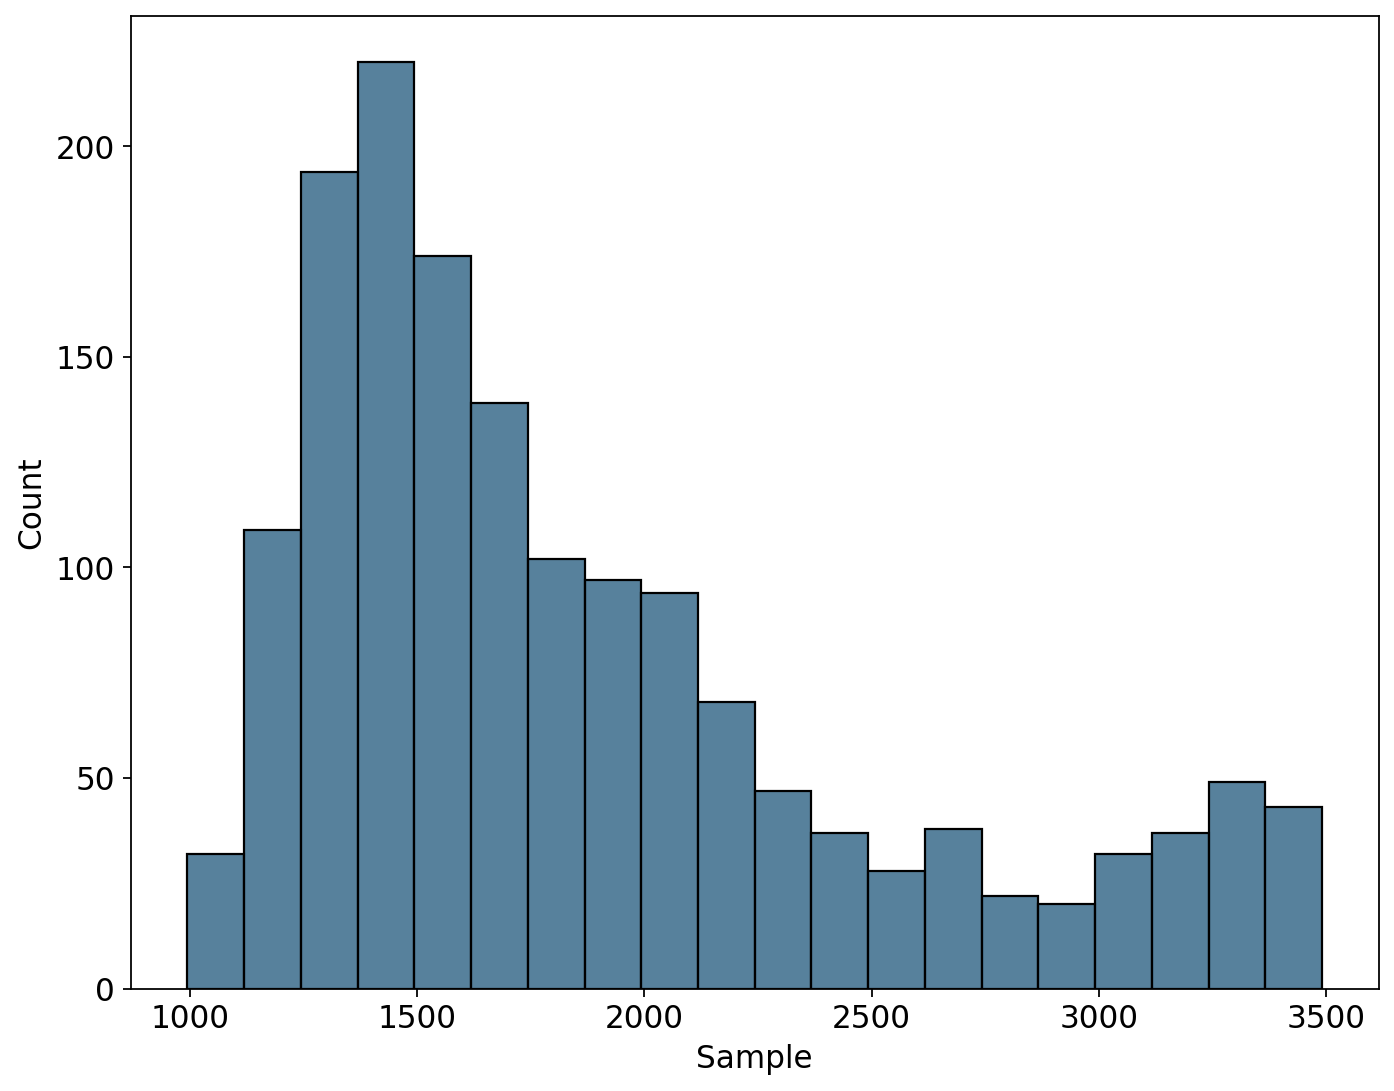

finish QC: WT
process qc finished in 0.14449422201141715 secs.


make_networks  processing time:  12.234641157090664
process nc finished in 12.23484734701924 secs.
Using tensorly


(292, 292, 10)
tensor_decomp  processing time:  33.48072591307573
process td finished in 33.498009484959766 secs.
process ko finished in 0.0009841339197009802 secs.
manifold_alignment  processing time:  0.07854093192145228
process ma finished in 0.07859231508336961 secs.
d_regulation  processing time:  0.07418770994991064
process dr finished in 0.07423444301821291 secs.


[ov.single.perturb] target='Gata1' mode='ko' backend='sctenifoldknk'  — top 10 downstream genes by |Δexpr|:
 gene    delta  boxcox-transformed distance        Z    log2_fc      p-value  adjusted p-value  mean_base  mean_pert
Gata1 0.000048                    -8.922000 1.640916 178.221333 1.185184e-40      3.460739e-38        NaN        NaN
 Car2 0.000033                    -9.217279 1.592658  85.039931 2.924000e-20      4.269041e-18        NaN        NaN
 Nkg7 0.000012                   -10.041482 1.457956  10.433426 1.237550e-03      1.204549e-01        NaN        NaN
  Emb 0.000009                   -10.267218 1.421064   5.822489 1.582254e-02      1.000000e+00        NaN        NaN
 Cpa3 0.000007                   -10.390139 1.400974   4.231298 3.968508e-02      1.000000e+00        NaN        NaN
 Cd53 0.000007                   -10.469413 1.388019   3.441949 6.356068e-02      1.000000e+00        NaN        NaN
 Apoe 0.000004                   -10.957865 1.308190   0.954339 3.286172e

,gene,delta,boxcox-transformed distance,Z,log2_fc,p-value,adjusted p-value,mean_base,mean_pert
97,Gata1,0.000048,-8.922000,1.640916,178.221333,1.185184e-40,3.460739e-38,NaN,NaN
30,Car2,0.000033,-9.217279,1.592658,85.039931,2.924000e-20,4.269041e-18,NaN,NaN
186,Nkg7,0.000012,-10.041482,1.457956,10.433426,1.237550e-03,1.204549e-01,NaN,NaN
79,Emb,0.000009,-10.267218,1.421064,5.822489,1.582254e-02,1.000000e+00,NaN,NaN
60,Cpa3,0.000007,-10.390139,1.400974,4.231298,3.968508e-02,1.000000e+00,NaN,NaN
48,Cd53,0.000007,-10.469413,1.388019,3.441949,6.356068e-02,1.000000e+00,NaN,NaN
13,Apoe,0.000004,-10.957865,1.308190,0.954339,3.286172e-01,1.000000e+00,NaN,NaN
156,Lsp1,0.000003,-11.051053,1.292960,0.745605,3.878712e-01,1.000000e+00,NaN,NaN
178,Muc13,0.000002,-11.486148,1.221851,0.233391,6.290205e-01,1.000000e+00,NaN,NaN
46,Cd34,0.000002,-11.564024,1.209124,0.189281,6.635154e-01,1.000000e+00,NaN,NaN


In [4]:
%%time
result = ov.single.perturb(
    adata_sub, target='Gata1', mode='ko',
    backend='sctenifoldknk',
)
result.summary(top_n=10)

## 3. Δ-GRN — which edges changed?

`result.delta_grn` is the long-format edge-weight diff table. For a
KO the changed edges are exactly the in / out edges of the target.

In [5]:
dg = result.delta_grn.copy()
out = dg[dg['source'] == 'Gata1'].reindex(
    dg[dg['source'] == 'Gata1']['delta'].abs().sort_values(ascending=False).index
)
out.head(10)

,source,target,weight_base,weight_pert,delta
2937,Gata1,C1qtnf12,0.3,0.0,-0.3
2931,Gata1,Aqp1,0.3,0.0,-0.3
2936,Gata1,Blvrb,0.3,0.0,-0.3
2938,Gata1,Car1,0.3,0.0,-0.3
2957,Gata1,Epor,0.3,0.0,-0.3
2996,Gata1,Smim1,0.3,0.0,-0.3
2989,Gata1,Rhd,0.3,0.0,-0.3
2974,Gata1,Klf1,0.3,0.0,-0.3
2958,Gata1,Ermap,0.3,0.0,-0.3
2933,Gata1,Atp1b2,0.2,0.0,-0.2


## 4. KO vs OE — same call, different `mode`

Removed 7 cells with lib size < 1000
Removed 56 outlier cells from original data
Removed 296 genes expressed in less than 0.05 of data
Removed 13 genes with expression values: average < 0.05 or sum < 25


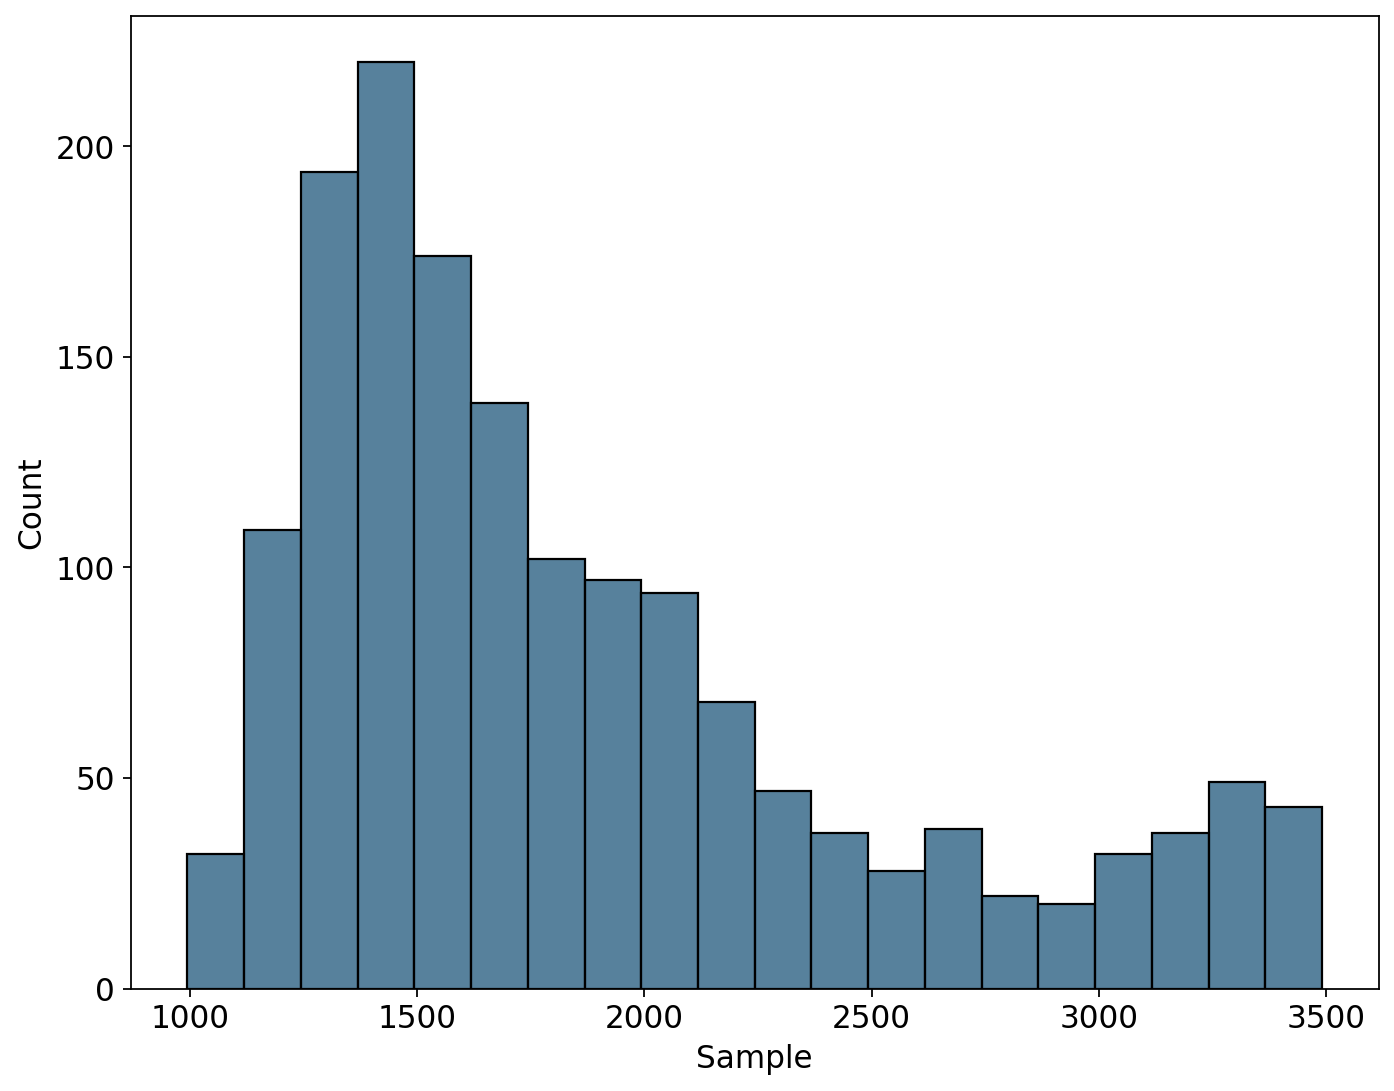

finish QC: WT
process qc finished in 0.2831496139988303 secs.


make_networks  processing time:  133.18374719307758
process nc finished in 133.18432071409188 secs.
Using tensorly


(292, 292, 10)
tensor_decomp  processing time:  34.45623148093
process td finished in 34.463287215912715 secs.
process ko finished in 0.001167028909549117 secs.
manifold_alignment  processing time:  0.12809377606026828
process ma finished in 0.12815342005342245 secs.
d_regulation  processing time:  0.060324507066980004
process dr finished in 0.06037021498195827 secs.


[ov.single.perturb] target='Gata1' mode='oe' backend='sctenifoldknk'  — top 10 downstream genes by |Δexpr|:
    gene  mean_base  mean_pert  delta  log2_fc
   Gata1        9.0       27.0   18.0 1.584962
   Smim1       14.5       15.1    0.6 0.058496
C1qtnf12       15.1       15.7    0.6 0.056216
   Ermap       16.1       16.7    0.6 0.052787
    Epor       14.2       14.8    0.6 0.059706
    Klf1       15.3       15.9    0.6 0.055495
   Blvrb       15.9       16.5    0.6 0.053439
    Car1       14.2       14.8    0.6 0.059706
     Rhd       15.9       16.5    0.6 0.053439
    Aqp1       14.2       14.8    0.6 0.059706


,gene,mean_base,mean_pert,delta,log2_fc
97,Gata1,9.0,27.0,18.0,1.584962
248,Smim1,14.5,15.1,0.6,0.058496
27,C1qtnf12,15.1,15.7,0.6,0.056216
83,Ermap,16.1,16.7,0.6,0.052787
82,Epor,14.2,14.8,0.6,0.059706
149,Klf1,15.3,15.9,0.6,0.055495
24,Blvrb,15.9,16.5,0.6,0.053439
29,Car1,14.2,14.8,0.6,0.059706
218,Rhd,15.9,16.5,0.6,0.053439
14,Aqp1,14.2,14.8,0.6,0.059706


In [6]:
result_oe = ov.single.perturb(
    adata_sub, target='Gata1', mode='oe', fold_change=3.0,
    backend='sctenifoldknk',
)
result_oe.summary(top_n=10)

## 5. Parity vs raw `scTenifold.scTenifoldKnk`

`ov.single.perturb(backend='sctenifoldknk')` is a thin wrapper around
the upstream class. The deterministic columns (Distance, FC, p, adj p)
match to floating-point noise; Z + boxcox depend on the tensor's
random initialisation and differ slightly between runs of either
implementation.

Removed 7 cells with lib size < 1000
Removed 56 outlier cells from original data
Removed 296 genes expressed in less than 0.05 of data
Removed 13 genes with expression values: average < 0.05 or sum < 25


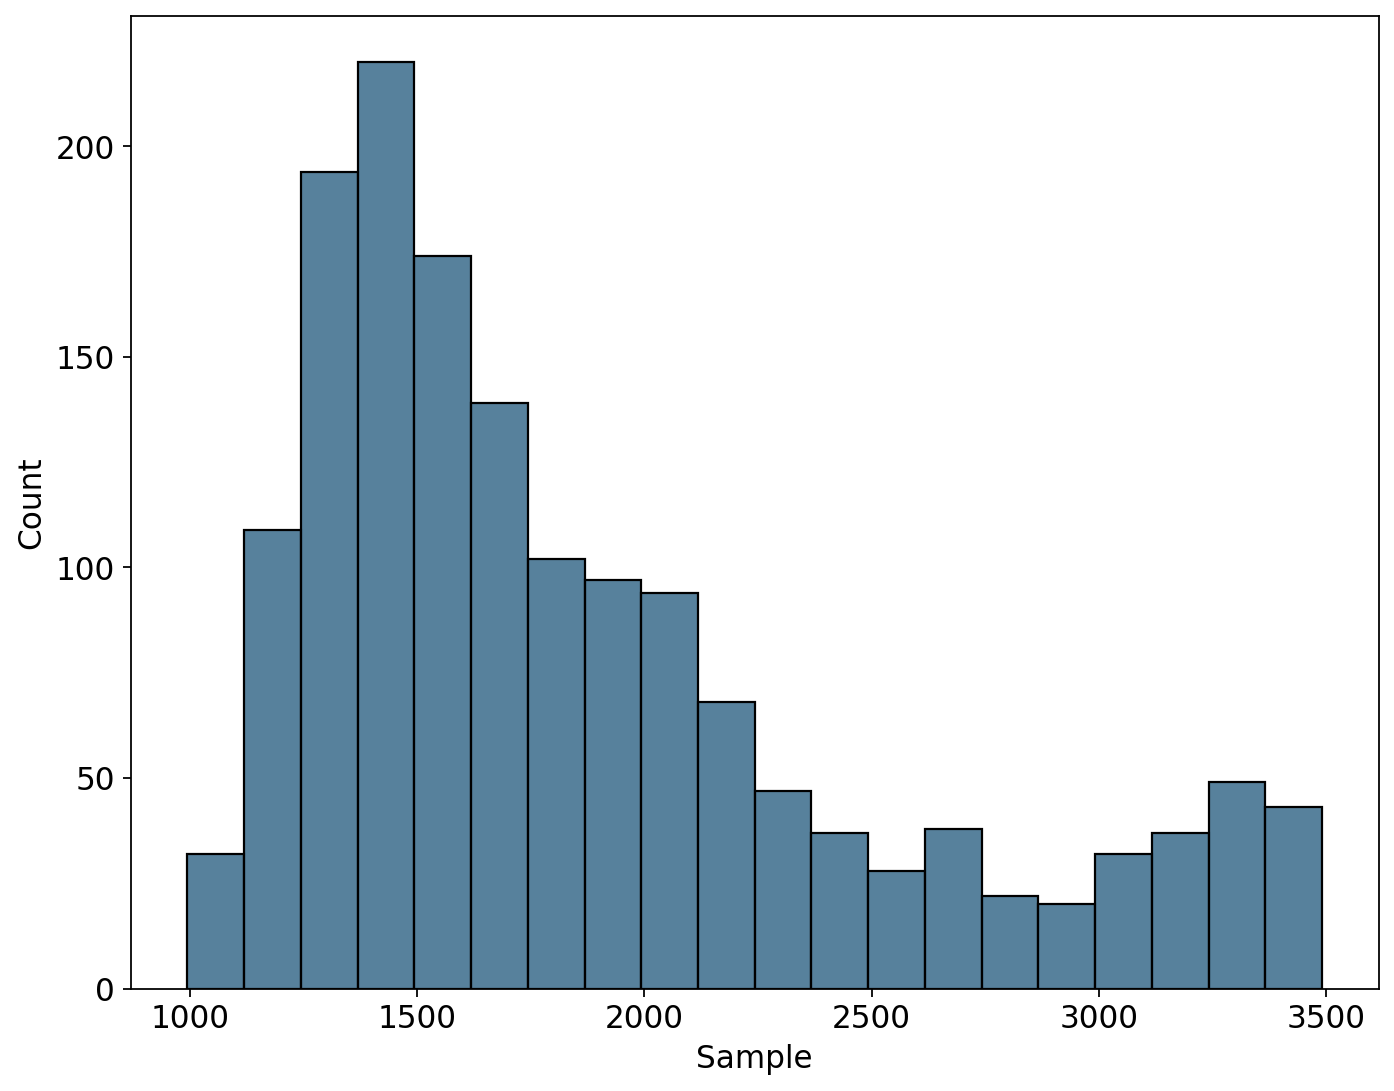

finish QC: WT
process qc finished in 0.14260288304649293 secs.


make_networks  processing time:  13.983181854942814
process nc finished in 13.983440556097776 secs.
Using tensorly


(292, 292, 10)
tensor_decomp  processing time:  30.241760689066723
process td finished in 30.2486034729518 secs.
process ko finished in 0.0016868570819497108 secs.
manifold_alignment  processing time:  0.06696127192117274
process ma finished in 0.06701625604182482 secs.
d_regulation  processing time:  0.10360407712869346
process dr finished in 0.10364837083034217 secs.


In [7]:
import scTenifold as sct, numpy as np, pandas as pd

counts_df = pd.DataFrame(
    adata_sub.X.toarray() if hasattr(adata_sub.X, 'toarray') else np.asarray(adata_sub.X),
    index=adata_sub.obs_names.astype(str),
    columns=adata_sub.var_names.astype(str),
).T
knk = sct.scTenifoldKnk(data=counts_df, ko_genes=['Gata1'])
knk.build()
raw_dreg = knk.d_regulation.set_index('Gene')

In [8]:
ov_dreg = result.delta_expr.set_index('gene')
pairs = [('Distance', 'delta'), ('FC', 'log2_fc'),
         ('p-value', 'p-value'), ('adjusted p-value', 'adjusted p-value')]
shared = sorted(set(raw_dreg.index) & set(ov_dreg.index))
rows = []
for r, o in pairs:
    if r in raw_dreg.columns and o in ov_dreg.columns:
        a = pd.to_numeric(raw_dreg.loc[shared, r], errors='coerce').to_numpy()
        b = pd.to_numeric(ov_dreg.loc[shared, o], errors='coerce').to_numpy()
        rows.append({'col': f'{r} ↔ {o}',
                     'max |Δ|': float(np.nanmax(np.abs(a - b))),
                     'allclose': bool(np.allclose(a, b, atol=1e-8, equal_nan=True))})
pd.DataFrame(rows)

,col,max |Δ|,allclose
0,Distance ↔ delta,6.377199e-16,True
1,FC ↔ log2_fc,8.397905e-10,True
2,p-value ↔ p-value,1.344470e-10,True
3,adjusted p-value ↔ adjusted p-value,1.158909e-11,True


## 6. Save / load — skip the PCNet rebuild next time

In [9]:
result.save('/tmp/gata1_ko_nestorowa.pkl')
result = ov.single.PerturbResult.load('/tmp/gata1_ko_nestorowa.pkl')

💾 Save Operation:
   Target path: /tmp/gata1_ko_nestorowa.pkl
   Object type: PerturbResult
   Using: pickle
   ✅ Successfully saved!
────────────────────────────────────────────────────────────
📂 Load Operation:
   Source path: /tmp/gata1_ko_nestorowa.pkl
   Using: pickle
   ✅ Successfully loaded!
   Loaded object type: PerturbResult
────────────────────────────────────────────────────────────


## 7. Same data, same UMAP, same downstream as the `cell_oracle` tutorial

For an apples-to-apples cross-backend comparison we re-run
`sctenifoldknk` on the **official Paul15 dataset + force-directed
UMAP** used in
[`t_perturb_celloracle`](t_perturb_celloracle.ipynb) so the figures
line up panel-by-panel.

In [10]:
import celloracle as co

adata_p15 = co.data.load_Paul2015_data()
adata_p15.X = adata_p15.layers['raw_count'].copy()
adata_p15.var_names = adata_p15.var_names.astype(str)
adata_p15.obsm['X_umap'] = adata_p15.obsm['X_draw_graph_fa'][:, :2].copy()
adata_p15.obs['main_cluster'] = (adata_p15.obs['louvain_annot'].astype(str)
                                 .str.split('_').str[0])

In [11]:
# `highly_variable_genes` with `flavor='seurat_v3'` works on raw counts
ov.pp.highly_variable_genes(adata_p15, n_top_genes=500, flavor='seurat_v3')
KEEP = ['Gata1','Klf1','Spi1','Gata2','Cebpa','Tal1','Runx1',
        'Hbb-bt','Hbb-bs','Hba-a1','Hba-a2','Alas2','Gypa',
        'Slc4a1','Epor','Mpo','Lyz2','Elane']
mask = adata_p15.var['highly_variable'].copy()
for g in KEEP:
    if g in adata_p15.var_names: mask[g] = True
adata_p15 = adata_p15[:, mask].copy()


🔍 Highly Variable Genes Selection:
   Method: seurat_v3
   Target genes: 500
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'variances_norm': Float vector (adata.var)

╭─ SUMMARY: highly_variable_genes ───────────────────────────────────╮
│  Duration: 0.1309s                                                 │
│  Shape:    2,671 x 1,999 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ highly_variable (bool)                               │
│           │ ✚ highly_variable_rank (float)                         │
│           │ ✚ means (float)                                        │

In [12]:
ov.single.lineage_pseudotime(
    adata_p15,
    lineage_dictionary={
        'Lineage_ME': ['Ery_0','Ery_1','Ery_2','Ery_3','Ery_4','Ery_5',
                       'Ery_6','Ery_7','Ery_8','Ery_9','MEP_0','Mk_0'],
        'Lineage_GM': ['GMP_0','GMP_1','GMP_2','GMPl_0','GMPl_1','Gran_0',
                       'Gran_1','Gran_2','Gran_3','Mo_0','Mo_1','Mo_2'],
    },
    root_cells={'Lineage_ME': '1539', 'Lineage_GM': '2244'},
    obsm_key='X_draw_graph_fa',
    cluster_column_name='louvain_annot',
)

AnnData object with n_obs × n_vars = 2671 × 504
    obs: 'paul15_clusters', 'n_counts_all', 'n_counts', 'louvain', 'cell_type', 'louvain_annot', 'dpt_pseudotime', 'main_cluster', 'Pseudotime'
    var: 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'diffmap_evals', 'draw_graph', 'iroot', 'louvain', 'louvain_annot_colors', 'louvain_colors', 'louvain_sizes', 'neighbors', 'paga', 'paul15_clusters_colors', 'pca', 'hvg', '_ov_provenance', 'history_log'
    obsm: 'X_diffmap', 'X_draw_graph_fa', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_count'
    obsp: 'connectivities', 'distances'

In [13]:
result_p15 = ov.single.perturb(
    adata_p15, target='Gata1', mode='ko', backend='sctenifoldknk',
    backend_kwargs={'qc_kws': {'min_lib_size': 100}},
)
result_p15.summary(top_n=10)

Removed 0 cells with lib size < 100
Removed 2 outlier cells from original data
Removed 212 genes expressed in less than 0.05 of data
Removed 0 genes with expression values: average < 0.05 or sum < 25
finish QC: WT
process qc finished in 0.06969244196079671 secs.


make_networks  processing time:  11.489030140917748
process nc finished in 11.48959996085614 secs.
Using tensorly


(292, 292, 10)
tensor_decomp  processing time:  46.303937764139846
process td finished in 46.309580909088254 secs.
process ko finished in 0.0011837310157716274 secs.
manifold_alignment  processing time:  0.10842957999557257
process ma finished in 0.10850135097280145 secs.


d_regulation  processing time:  0.0897471159696579
process dr finished in 0.089925471926108 secs.


[ov.single.perturb] target='Gata1' mode='ko' backend='sctenifoldknk'  — top 10 downstream genes by |Δexpr|:
   gene    delta  boxcox-transformed distance        Z    log2_fc      p-value  adjusted p-value  mean_base  mean_pert
  Gata1 0.001602                    -5.741947 2.001514 272.464076 3.295214e-61      9.622024e-59        NaN        NaN
   Car2 0.000254                    -7.153561 1.687918   6.847717 8.875462e-03      1.000000e+00        NaN        NaN
Fam132a 0.000247                    -7.174797 1.683201   6.466168 1.099473e-02      1.000000e+00        NaN        NaN
  Blvrb 0.000097                    -7.856459 1.531766   0.993933 3.187829e-01      1.000000e+00        NaN        NaN
   Car1 0.000091                    -7.903014 1.521424   0.872558 3.502481e-01      1.000000e+00        NaN        NaN
   Cpox 0.000064                    -8.151857 1.466142   0.432689 5.106722e-01      1.000000e+00        NaN        NaN
   Klf1 0.000060                    -8.193953 1.456790   0.

,gene,delta,boxcox-transformed distance,Z,log2_fc,p-value,adjusted p-value,mean_base,mean_pert
106,Gata1,0.001602,-5.741947,2.001514,272.464076,3.295214e-61,9.622024e-59,NaN,NaN
25,Car2,0.000254,-7.153561,1.687918,6.847717,8.875462e-03,1.000000e+00,NaN,NaN
81,Fam132a,0.000247,-7.174797,1.683201,6.466168,1.099473e-02,1.000000e+00,NaN,NaN
22,Blvrb,0.000097,-7.856459,1.531766,0.993933,3.187829e-01,1.000000e+00,NaN,NaN
24,Car1,0.000091,-7.903014,1.521424,0.872558,3.502481e-01,1.000000e+00,NaN,NaN
50,Cpox,0.000064,-8.151857,1.466142,0.432689,5.106722e-01,1.000000e+00,NaN,NaN
156,Klf1,0.000060,-8.193953,1.456790,0.383938,5.355031e-01,1.000000e+00,NaN,NaN
75,Ermap,0.000060,-8.199546,1.455548,0.377882,5.387391e-01,1.000000e+00,NaN,NaN
187,Mt2,0.000057,-8.237085,1.447209,0.339587,5.600675e-01,1.000000e+00,NaN,NaN
214,Prdx2,0.000053,-8.279915,1.437694,0.300537,5.835459e-01,1.000000e+00,NaN,NaN


### 7.1 CellOracle's official 6-panel — works on `sctenifoldknk` too

`ov.pl.perturb_celloracle_layout` wraps any backend's `PerturbResult`
in an Oracle-compatible adapter, then runs CellOracle's own
`Oracle_development_module.visualize_development_module_layout_0` —
guaranteeing the published figure layout regardless of which backend
produced the per-cell ΔX.

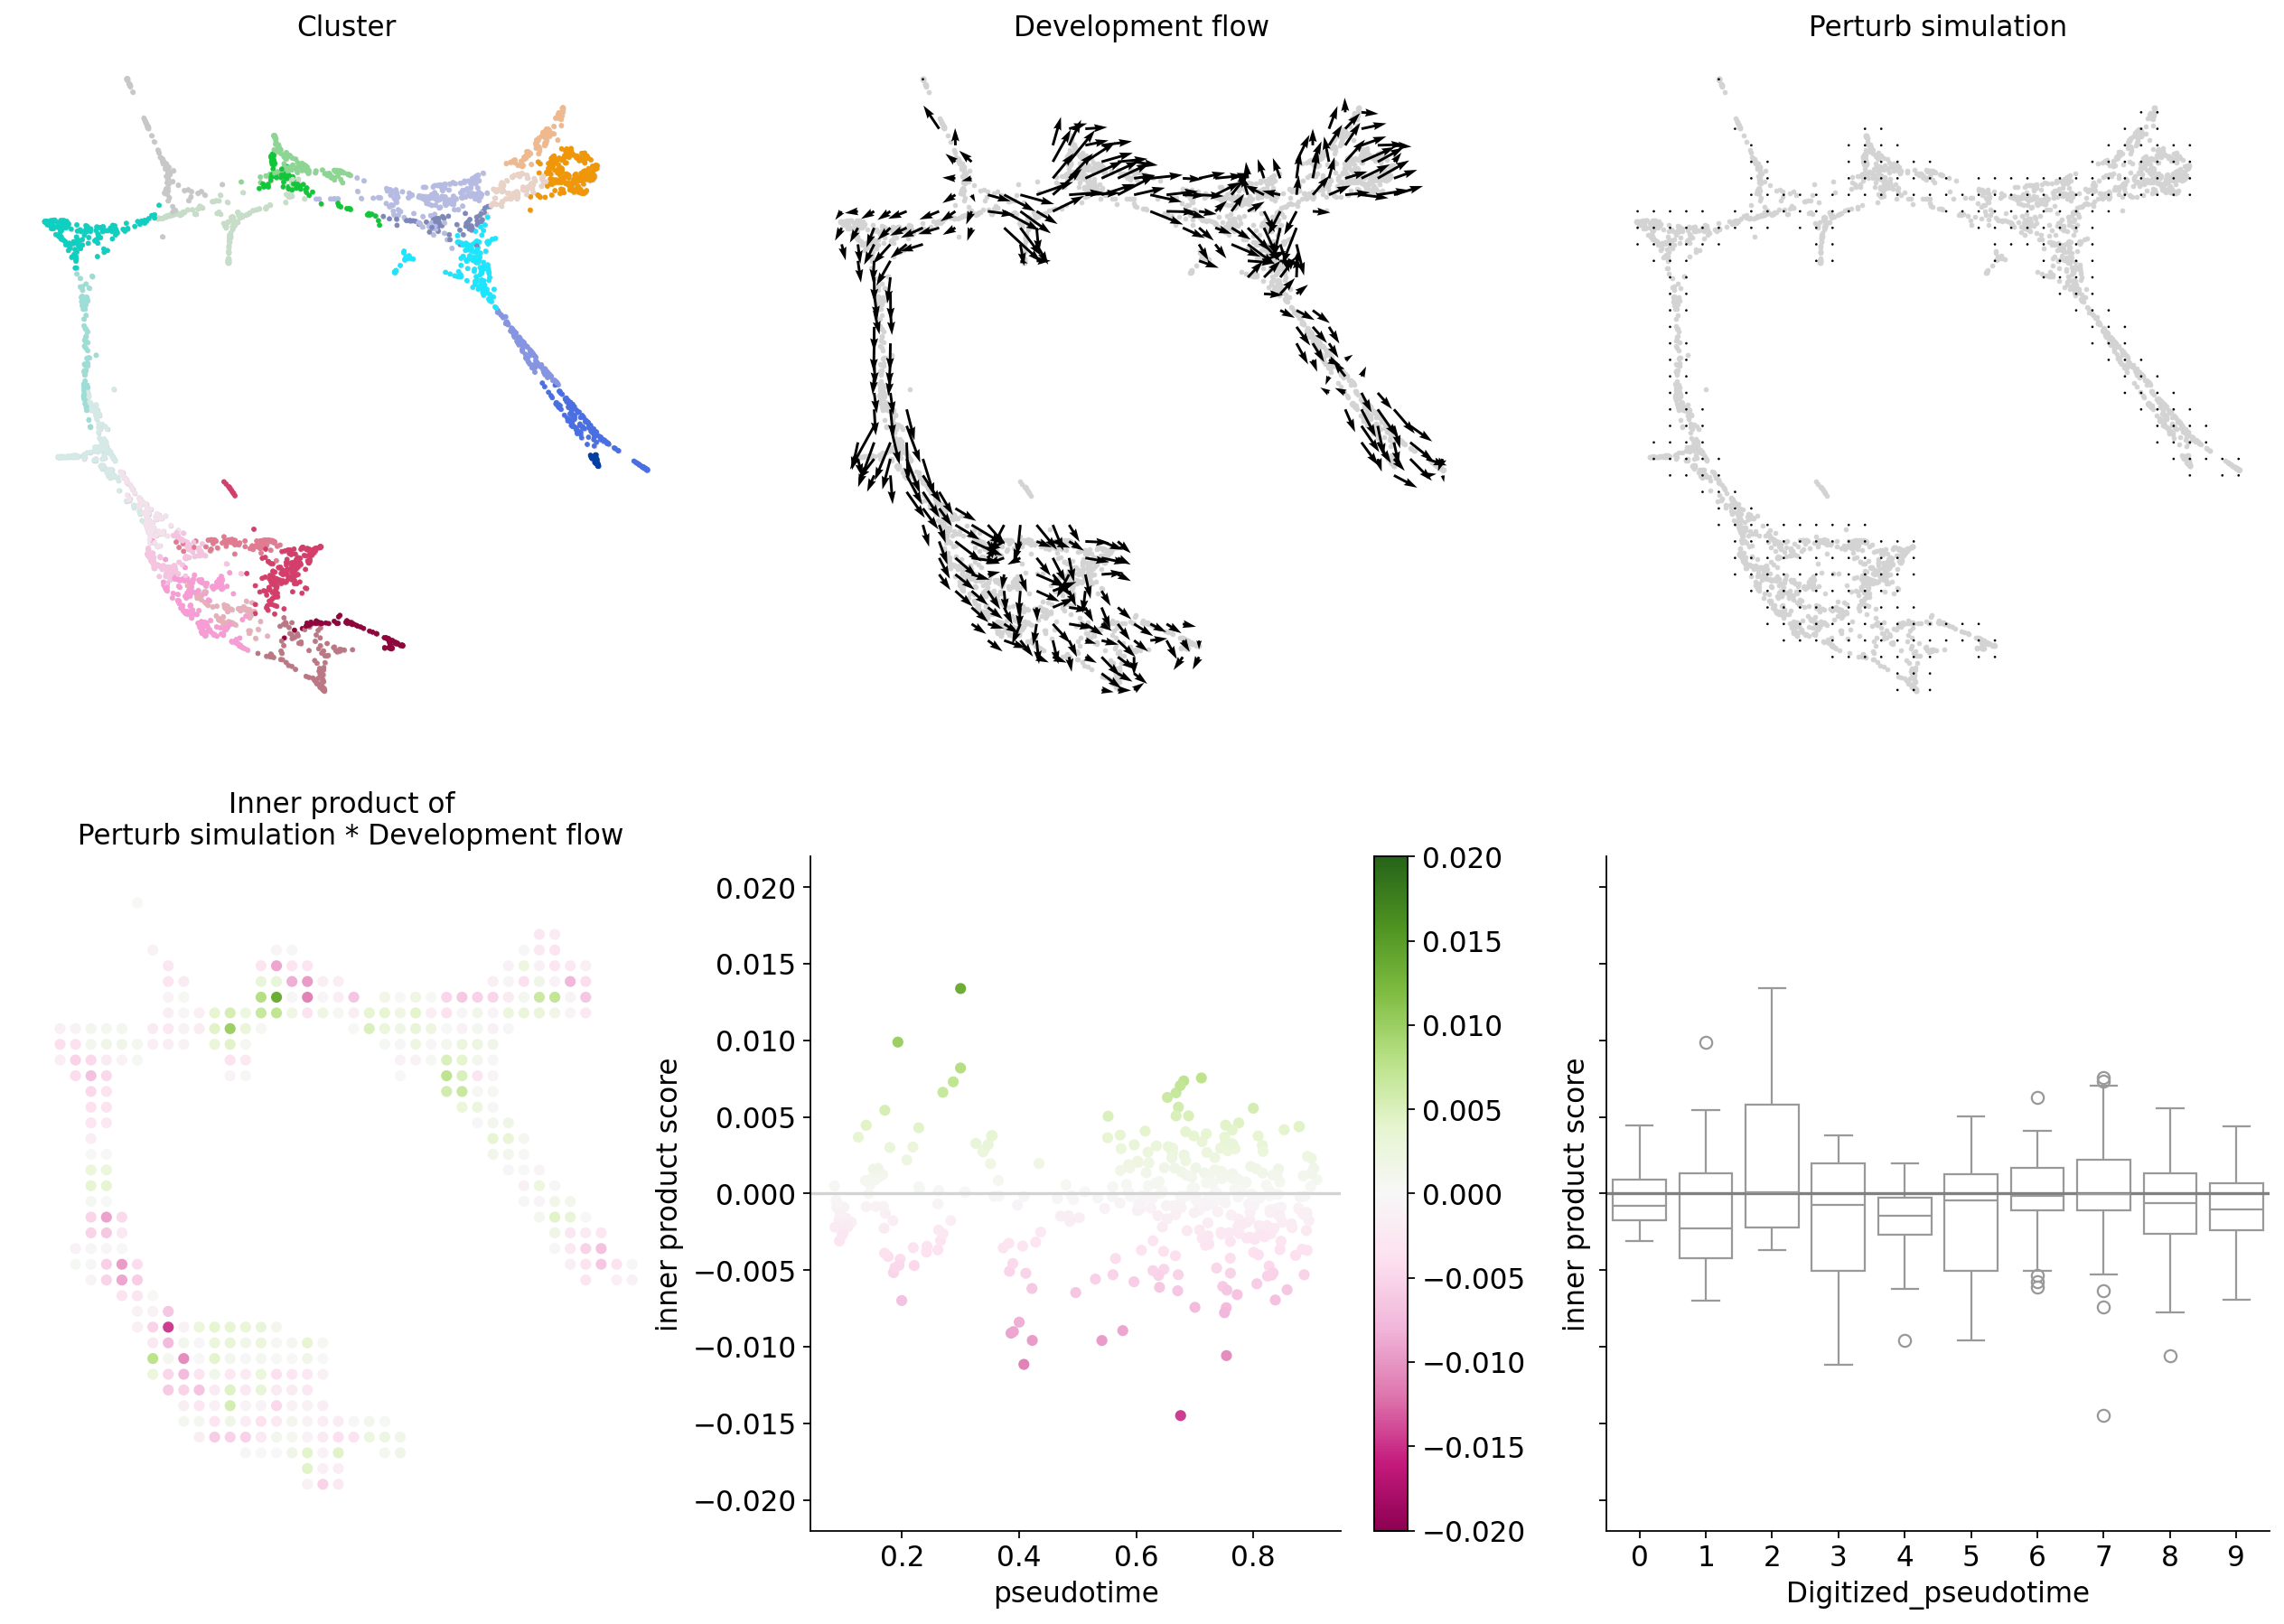

In [14]:
fig, _ = ov.pl.perturb_celloracle_layout(
    adata_p15, result_p15,
    pseudotime_key='Pseudotime',
    cluster_column_name='louvain_annot',
    vm=0.02,
)
fig

### 7.2 Sankey + Markov endpoints

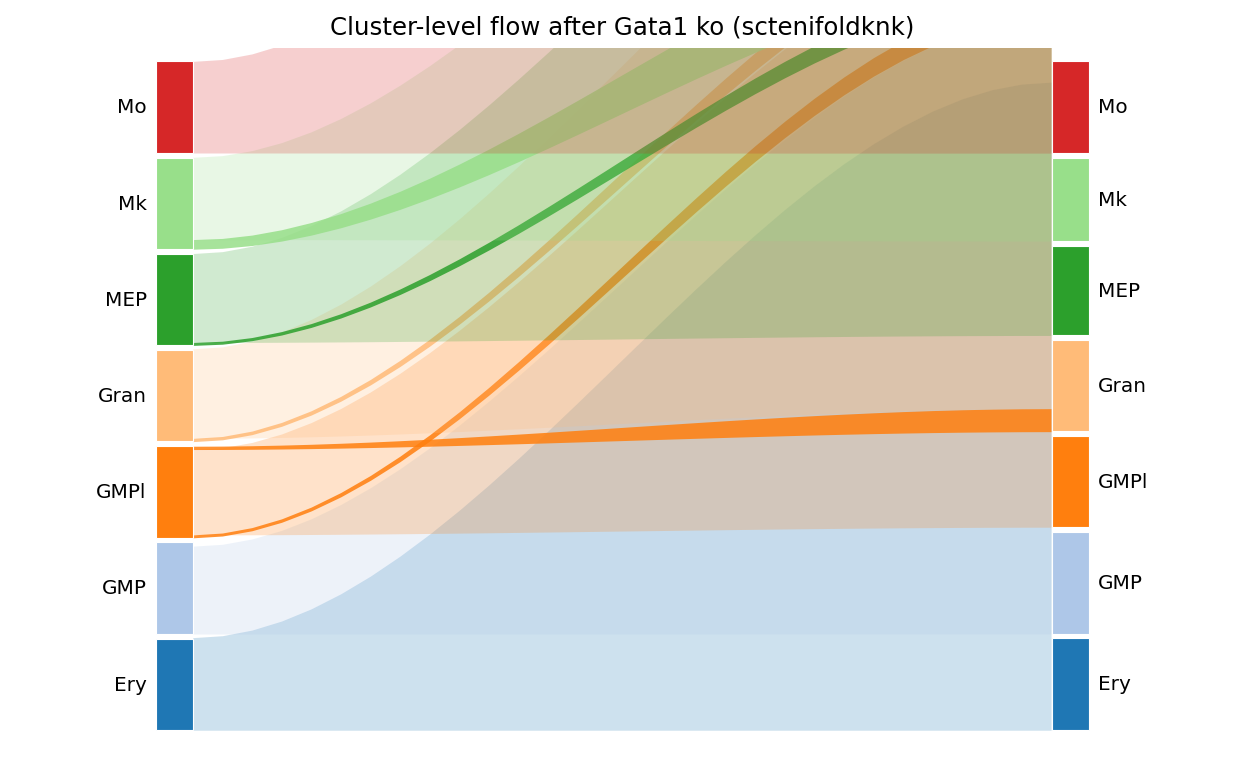

In [15]:
fig, _ = ov.pl.perturb_sankey(result_p15, adata=adata_p15,
                              cluster_col='main_cluster', min_flow=0.03)
fig

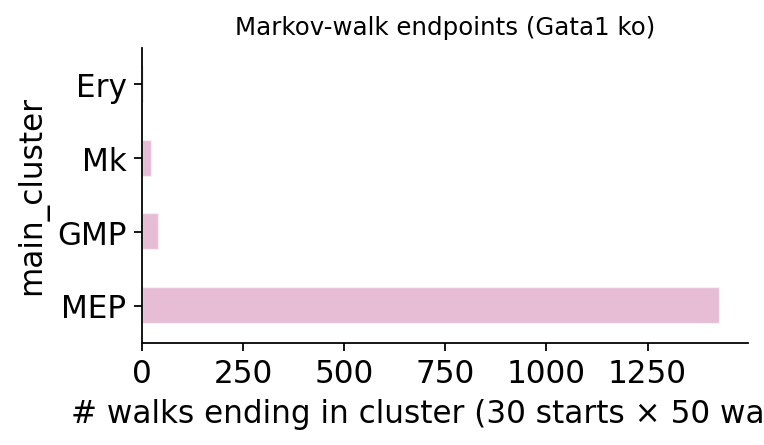

In [16]:
mep_cells = adata_p15.obs_names[adata_p15.obs['main_cluster'] == 'MEP'][:30]
fig, _ = ov.pl.perturb_markov_endpoints(
    result_p15, adata=adata_p15,
    start_cells=list(mep_cells), cluster_col='main_cluster',
    n_steps=15, n_walks_per_cell=50, color='C2',
)
fig

### 7.3 Volcano + enrichment

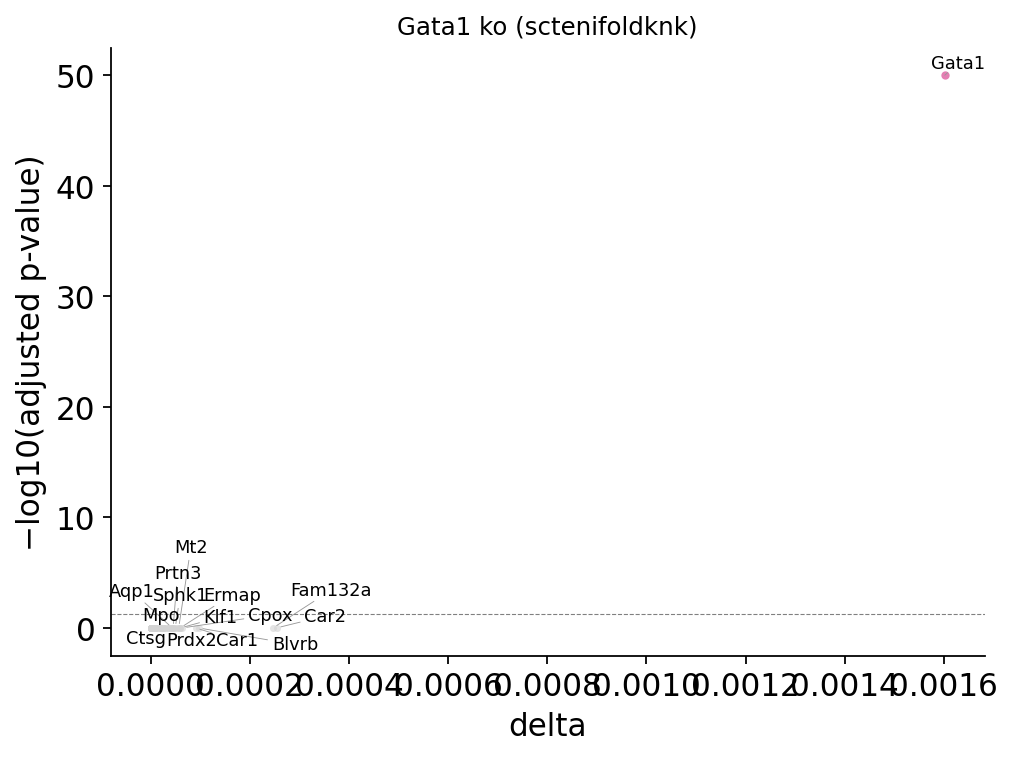

In [17]:
fig, _ = ov.pl.perturb_volcano(result_p15, top_n=15)
fig

In [18]:
mgi = result_p15.phenotype_enrichment(
    top_n=200,
    db='MGI_Mammalian_Phenotype_Level_4_2024',
    organism='mouse',
)
mgi.sort_values('Adjusted P-value').head(8)[
    ['Term', 'Adjusted P-value', 'Combined Score']
]

,Term,Adjusted P-value,Combined Score
0,Abnormal Common Myeloid Progenitor Cell Morpho...,1.176745e-08,654.071754
1,Abnormal Myelopoiesis MP:0001601,5.153793e-07,531.730952
2,"Decreased CD8-positive, Alpha-Beta T Cell Numb...",7.067101e-06,160.547697
3,Abnormal Definitive Hematopoiesis MP:0002123,1.342614e-05,212.150783
4,Impaired Hematopoiesis MP:0001606,1.616775e-05,306.651343
5,Abnormal Hematopoietic System Physiology MP:00...,2.763318e-05,545.405977
6,Decreased B Cell Number MP:0005017,7.331744e-05,98.632110
8,Abnormal Neutrophil Physiology MP:0002463,1.352165e-04,141.850086


## 8. Cross-backend agreement

| Section | API call | Works on `sctenifoldknk` | Works on `cell_oracle` |
|---|---|---|---|
| run | `ov.single.perturb(backend=...)` | ✓ | ✓ |
| save/load | `result.save` / `PerturbResult.load` | ✓ | ✓ |
| 6-panel | `ov.pl.perturb_celloracle_layout` | ✓ (via adapter) | ✓ |
| Sankey | `ov.pl.perturb_sankey` | ✓ | ✓ |
| Markov | `ov.pl.perturb_markov_endpoints` | ✓ | ✓ |
| volcano | `ov.pl.perturb_volcano` | ✓ | ✓ |
| enrichment | `result.{pathway,phenotype}_enrichment` | ✓ | ✓ |

## References

- Osorio, D. *et al.* **scTenifoldKnk.** *Patterns* 3, 100434 (2022).
- Nestorowa, S. *et al.* *Blood* 128, e20-e31 (2016) — the dataset.
- omicverse issue [#739](https://github.com/omicverse/omicverse/issues/739)
  motivated this module.